# Phase 2 — Exploratory Data Analysis (EDA)
### AI-Based Student Performance & Career Recommendation System
**University of South Asia, Lahore**

**Goal:** Data ko visually explore karo — patterns, relationships, aur insights nikalo.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')
os.makedirs('../plots', exist_ok=True)

# Color palette (project theme)
BLUE    = '#2563EB'
CYAN    = '#06B6D4'
GREEN   = '#10B981'
RED     = '#EF4444'
AMBER   = '#F59E0B'
NAVY    = '#0B1120'
GRAY    = '#6B7280'

plt.rcParams['figure.facecolor'] = '#111827'
plt.rcParams['axes.facecolor']   = '#1F2937'
plt.rcParams['axes.edgecolor']   = '#374151'
plt.rcParams['axes.labelcolor']  = 'white'
plt.rcParams['xtick.color']      = 'white'
plt.rcParams['ytick.color']      = 'white'
plt.rcParams['text.color']       = 'white'
plt.rcParams['grid.color']       = '#374151'
plt.rcParams['grid.alpha']       = 0.4

# Load clean data
df = pd.read_csv('../data/processed/student_clean.csv')
FEATURES = ['study_hours', 'attendance', 'prev_grade',
            'sleep_hours', 'extracurricular', 'gender']

print("Dataset loaded:", df.shape)
print(df.head())


Dataset loaded: (395, 8)
   study_hours  attendance  prev_grade  sleep_hours  extracurricular  gender  \
0          3.5        92.0        30.0          7.0                0       0   
1          3.5        94.7        25.0          7.0                0       0   
2          3.5        86.7        40.0          7.0                0       0   
3          7.5        97.3        70.0          6.0                1       0   
4          3.5        94.7        50.0          7.0                0       0   

   final_grade  pass_fail  
0         30.0          0  
1         30.0          0  
2         50.0          1  
3         75.0          1  
4         50.0          1  


## Step 1 — Basic Statistical Summary

In [2]:
print("=== Statistical Summary ===")
print(df.describe().round(2))
print()
print("=== Value Counts — Pass/Fail ===")
print(df['pass_fail'].value_counts())
print()
print("=== Value Counts — Gender ===")
print(df['gender'].value_counts().rename({1:'Male', 0:'Female'}))
print()
print("=== Value Counts — Extracurricular ===")
print(df['extracurricular'].value_counts().rename({1:'Yes', 0:'No'}))


=== Statistical Summary ===
       study_hours  attendance  prev_grade  sleep_hours  extracurricular  \
count       395.00      395.00      395.00       395.00           395.00   
mean          4.21       92.39       53.57         7.24             0.51   
std           2.86       10.67       18.81         1.00             0.50   
min           1.50        0.00        0.00         5.00             0.00   
25%           1.50       89.30       45.00         7.00             0.00   
50%           3.50       94.70       55.00         7.00             1.00   
75%           3.50      100.00       65.00         8.00             1.00   
max          12.00      100.00       95.00         9.00             1.00   

       gender  final_grade  pass_fail  
count  395.00       395.00     395.00  
mean     0.47        52.08       0.67  
std      0.50        22.91       0.47  
min      0.00         0.00       0.00  
25%      0.00        40.00       0.00  
50%      0.00        55.00       1.00  
75%    

## Step 2 — Final Grade Distribution

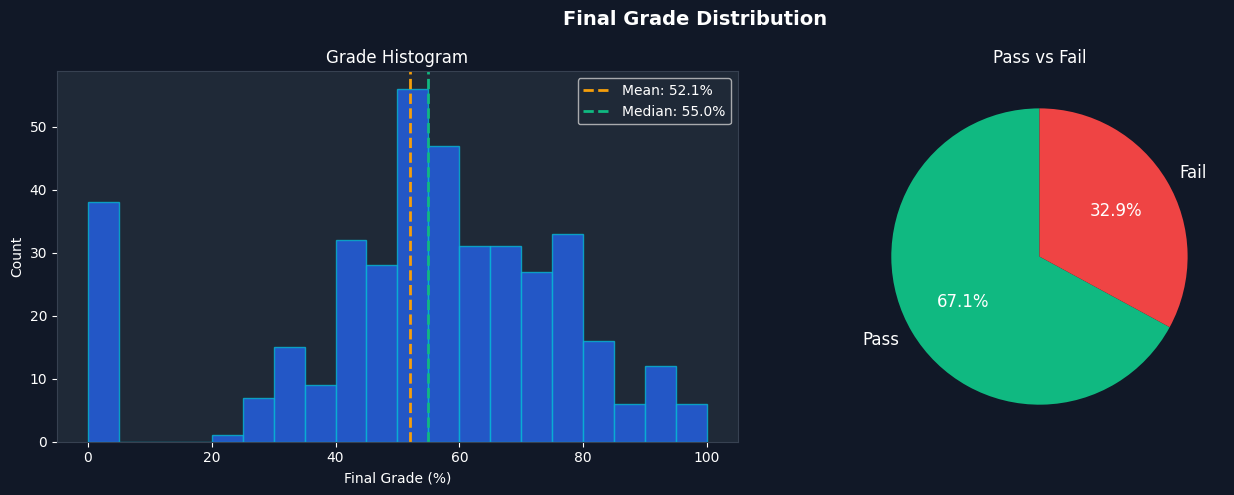

Saved: plots/grade_distribution.png


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Final Grade Distribution', color='white', fontsize=14, fontweight='bold')

# Histogram + KDE
axes[0].hist(df['final_grade'], bins=20, color=BLUE, alpha=0.8, edgecolor=CYAN)
axes[0].axvline(df['final_grade'].mean(), color=AMBER, linestyle='--', linewidth=2,
                label=f"Mean: {df['final_grade'].mean():.1f}%")
axes[0].axvline(df['final_grade'].median(), color=GREEN, linestyle='--', linewidth=2,
                label=f"Median: {df['final_grade'].median():.1f}%")
axes[0].set_xlabel('Final Grade (%)')
axes[0].set_ylabel('Count')
axes[0].set_title('Grade Histogram', color='white')
axes[0].legend()

# Pass/Fail pie
pass_c = df['pass_fail'].sum()
fail_c = len(df) - pass_c
axes[1].pie([pass_c, fail_c],
            labels=['Pass', 'Fail'],
            colors=[GREEN, RED],
            autopct='%1.1f%%',
            startangle=90,
            textprops={'color':'white', 'fontsize':12})
axes[1].set_title('Pass vs Fail', color='white')

plt.tight_layout()
plt.savefig('../plots/grade_distribution.png', dpi=150, bbox_inches='tight',
            facecolor='#111827')
plt.show()
print("Saved: plots/grade_distribution.png")


## Step 3 — Correlation Heatmap

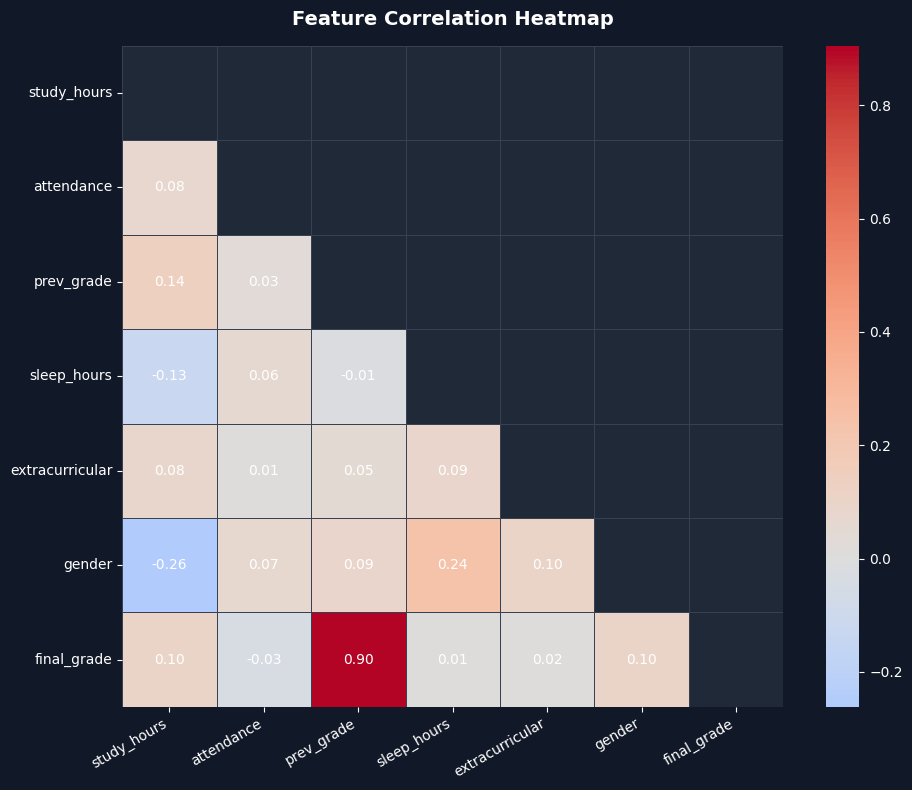

Saved: plots/correlation_heatmap.png

=== Correlation with Final Grade ===
prev_grade         0.905
gender             0.103
study_hours        0.102
extracurricular    0.016
sleep_hours        0.011
attendance        -0.034
Name: final_grade, dtype: float64


In [4]:
fig, ax = plt.subplots(figsize=(10, 8))

corr = df[FEATURES + ['final_grade']].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            mask=mask,
            square=True,
            linewidths=0.5,
            linecolor='#374151',
            ax=ax,
            annot_kws={'size': 10, 'color': 'white'})

ax.set_title('Feature Correlation Heatmap', color='white',
             fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig('../plots/correlation_heatmap.png', dpi=150,
            bbox_inches='tight', facecolor='#111827')
plt.show()
print("Saved: plots/correlation_heatmap.png")
print()
print("=== Correlation with Final Grade ===")
corr_target = df[FEATURES + ['final_grade']].corr()['final_grade'].drop('final_grade')
print(corr_target.sort_values(ascending=False).round(3))


## Step 4 — Study Hours vs Final Grade

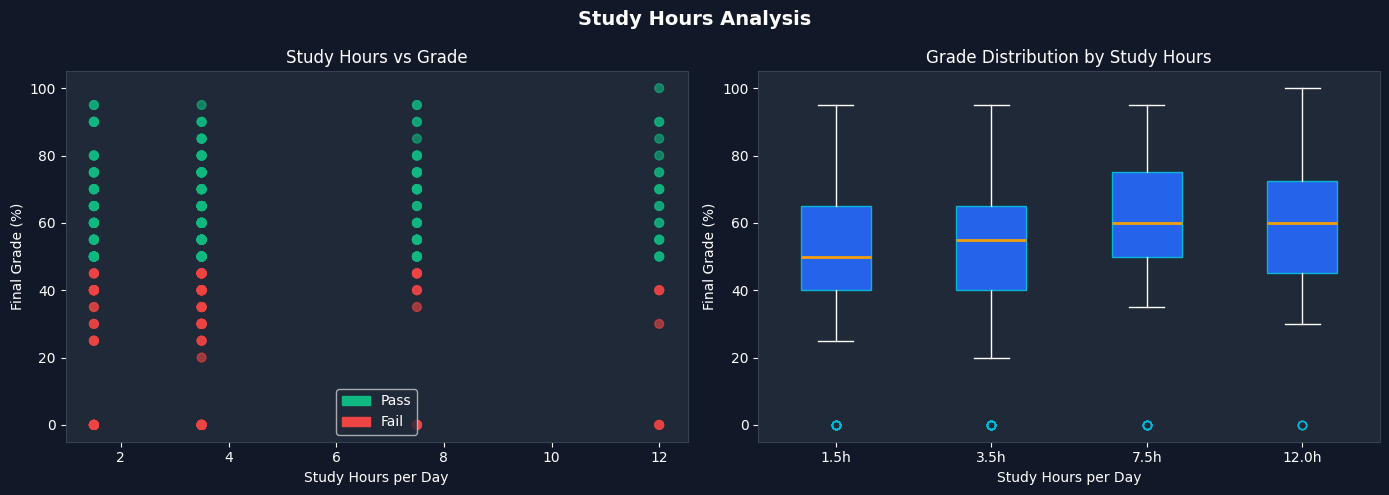

Saved: plots/study_hours_analysis.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Study Hours Analysis', color='white',
             fontsize=14, fontweight='bold')

# Scatter plot
colors = [GREEN if p == 1 else RED for p in df['pass_fail']]
axes[0].scatter(df['study_hours'], df['final_grade'],
                c=colors, alpha=0.6, s=40)
axes[0].set_xlabel('Study Hours per Day')
axes[0].set_ylabel('Final Grade (%)')
axes[0].set_title('Study Hours vs Grade', color='white')
pass_patch = mpatches.Patch(color=GREEN, label='Pass')
fail_patch = mpatches.Patch(color=RED,   label='Fail')
axes[0].legend(handles=[pass_patch, fail_patch])

# Boxplot by study hours
study_groups = df.groupby('study_hours')['final_grade'].apply(list)
axes[1].boxplot(study_groups.values,
                labels=[f"{h}h" for h in study_groups.index],
                patch_artist=True,
                boxprops=dict(facecolor=BLUE, color=CYAN),
                medianprops=dict(color=AMBER, linewidth=2),
                whiskerprops=dict(color='white'),
                capprops=dict(color='white'),
                flierprops=dict(color=CYAN, markeredgecolor=CYAN))
axes[1].set_xlabel('Study Hours per Day')
axes[1].set_ylabel('Final Grade (%)')
axes[1].set_title('Grade Distribution by Study Hours', color='white')

plt.tight_layout()
plt.savefig('../plots/study_hours_analysis.png', dpi=150,
            bbox_inches='tight', facecolor='#111827')
plt.show()
print("Saved: plots/study_hours_analysis.png")


## Step 5 — Attendance vs Final Grade

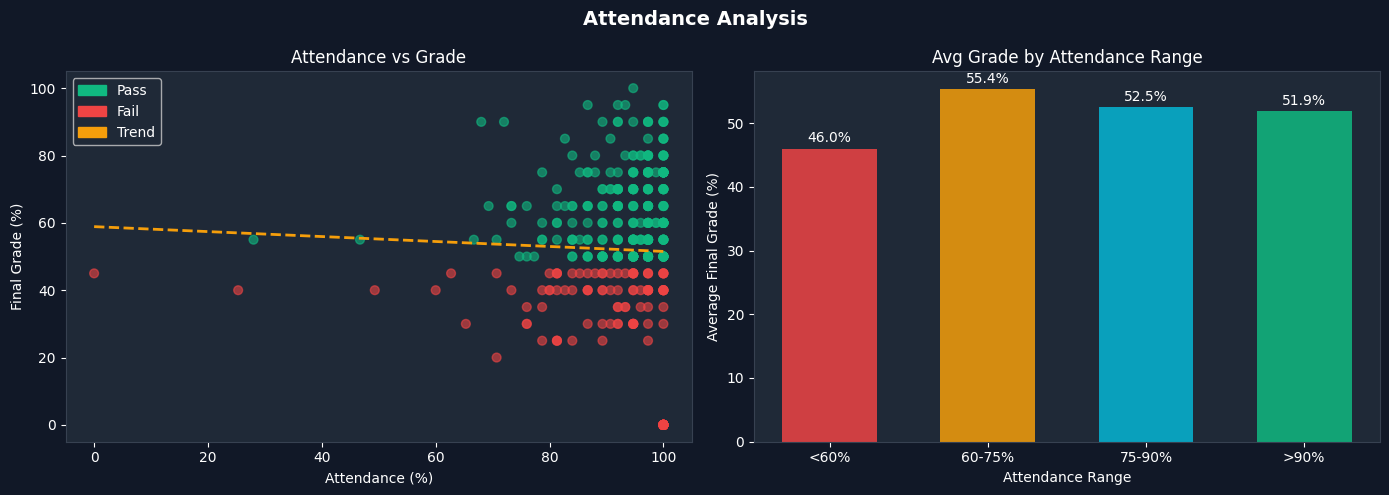

Saved: plots/attendance_analysis.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Attendance Analysis', color='white',
             fontsize=14, fontweight='bold')

# Scatter
axes[0].scatter(df['attendance'], df['final_grade'],
                c=colors, alpha=0.6, s=40)
z = np.polyfit(df['attendance'], df['final_grade'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['attendance'].min(), df['attendance'].max(), 100)
axes[0].plot(x_line, p(x_line), color=AMBER, linewidth=2,
             linestyle='--', label='Trend line')
axes[0].set_xlabel('Attendance (%)')
axes[0].set_ylabel('Final Grade (%)')
axes[0].set_title('Attendance vs Grade', color='white')
axes[0].legend(handles=[pass_patch, fail_patch,
                         mpatches.Patch(color=AMBER, label='Trend')])

# Attendance bins
df['att_bin'] = pd.cut(df['attendance'],
                        bins=[0, 60, 75, 90, 100],
                        labels=['<60%', '60-75%', '75-90%', '>90%'])
att_avg = df.groupby('att_bin', observed=True)['final_grade'].mean()
bars = axes[1].bar(att_avg.index, att_avg.values,
                   color=[RED, AMBER, CYAN, GREEN], alpha=0.85, width=0.6)
for bar, val in zip(bars, att_avg.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', va='bottom',
                 color='white', fontsize=10)
axes[1].set_xlabel('Attendance Range')
axes[1].set_ylabel('Average Final Grade (%)')
axes[1].set_title('Avg Grade by Attendance Range', color='white')

plt.tight_layout()
plt.savefig('../plots/attendance_analysis.png', dpi=150,
            bbox_inches='tight', facecolor='#111827')
plt.show()
print("Saved: plots/attendance_analysis.png")


## Step 6 — Previous Grade vs Final Grade

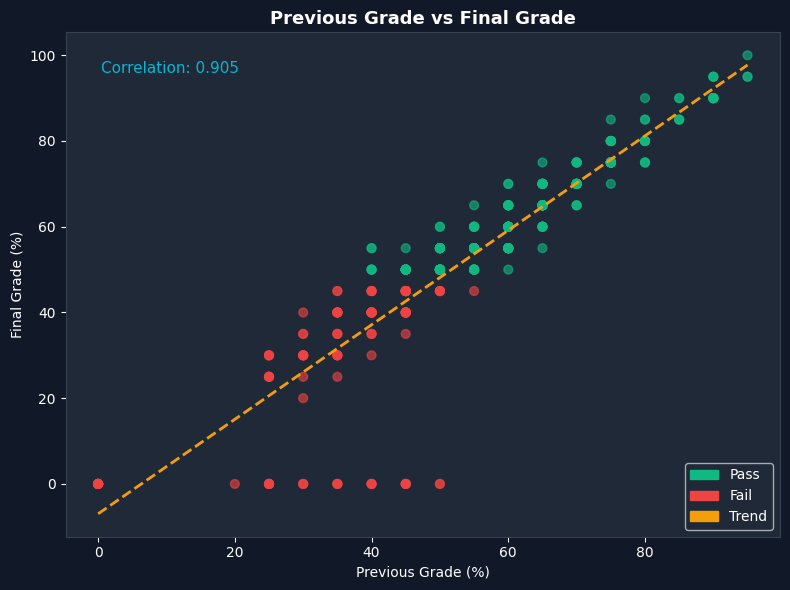

Saved: plots/prev_vs_final_grade.png
Correlation between prev_grade and final_grade: 0.905


In [7]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(df['prev_grade'], df['final_grade'],
           c=colors, alpha=0.6, s=40)

z = np.polyfit(df['prev_grade'], df['final_grade'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['prev_grade'].min(), df['prev_grade'].max(), 100)
ax.plot(x_line, p(x_line), color=AMBER, linewidth=2,
        linestyle='--', label='Trend line')

ax.set_xlabel('Previous Grade (%)')
ax.set_ylabel('Final Grade (%)')
ax.set_title('Previous Grade vs Final Grade', color='white',
             fontsize=13, fontweight='bold')
ax.legend(handles=[pass_patch, fail_patch,
                    mpatches.Patch(color=AMBER, label='Trend')])

corr_val = df['prev_grade'].corr(df['final_grade'])
ax.text(0.05, 0.92, f'Correlation: {corr_val:.3f}',
        transform=ax.transAxes, color=CYAN, fontsize=11)

plt.tight_layout()
plt.savefig('../plots/prev_vs_final_grade.png', dpi=150,
            bbox_inches='tight', facecolor='#111827')
plt.show()
print(f"Saved: plots/prev_vs_final_grade.png")
print(f"Correlation between prev_grade and final_grade: {corr_val:.3f}")


## Step 7 — All Features vs Final Grade

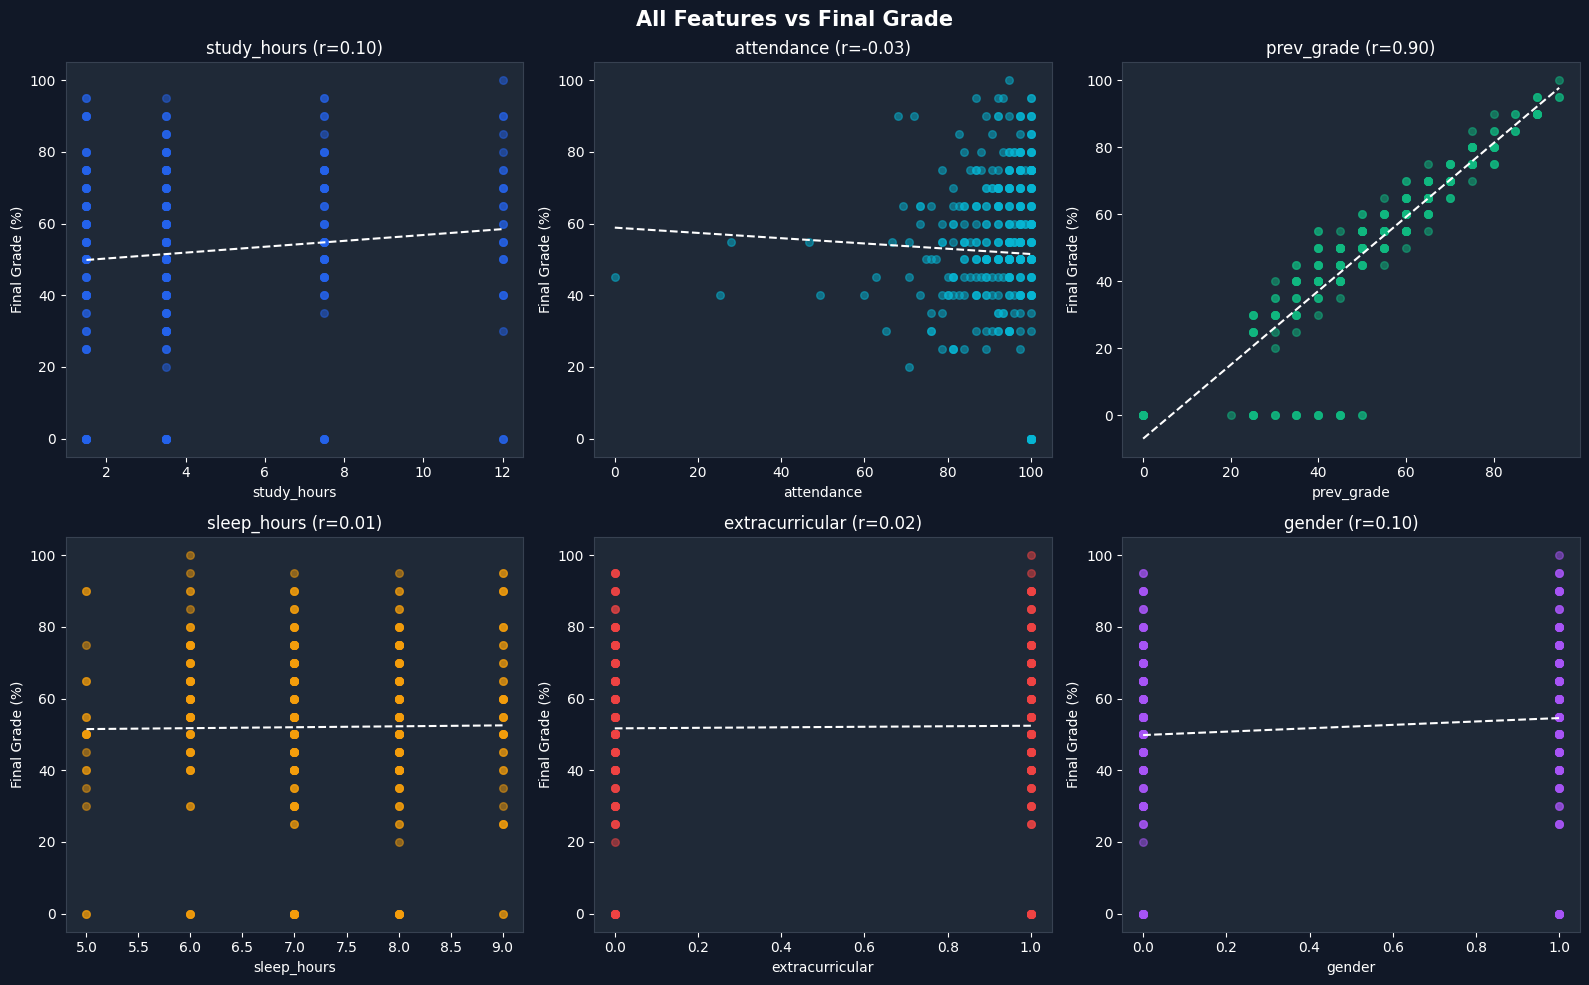

Saved: plots/all_features_vs_grade.png


In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('All Features vs Final Grade', color='white',
             fontsize=15, fontweight='bold')

feature_colors = [BLUE, CYAN, GREEN, AMBER, RED, '#A855F7']

for idx, (feat, color) in enumerate(zip(FEATURES, feature_colors)):
    ax  = axes[idx // 3][idx % 3]
    ax.scatter(df[feat], df['final_grade'], c=color, alpha=0.5, s=30)

    z = np.polyfit(df[feat], df['final_grade'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df[feat].min(), df[feat].max(), 100)
    ax.plot(x_line, p(x_line), color='white', linewidth=1.5, linestyle='--')

    corr_v = df[feat].corr(df['final_grade'])
    ax.set_xlabel(feat)
    ax.set_ylabel('Final Grade (%)')
    ax.set_title(f'{feat} (r={corr_v:.2f})', color='white')

plt.tight_layout()
plt.savefig('../plots/all_features_vs_grade.png', dpi=150,
            bbox_inches='tight', facecolor='#111827')
plt.show()
print("Saved: plots/all_features_vs_grade.png")


## Step 8 — Gender & Extracurricular Analysis

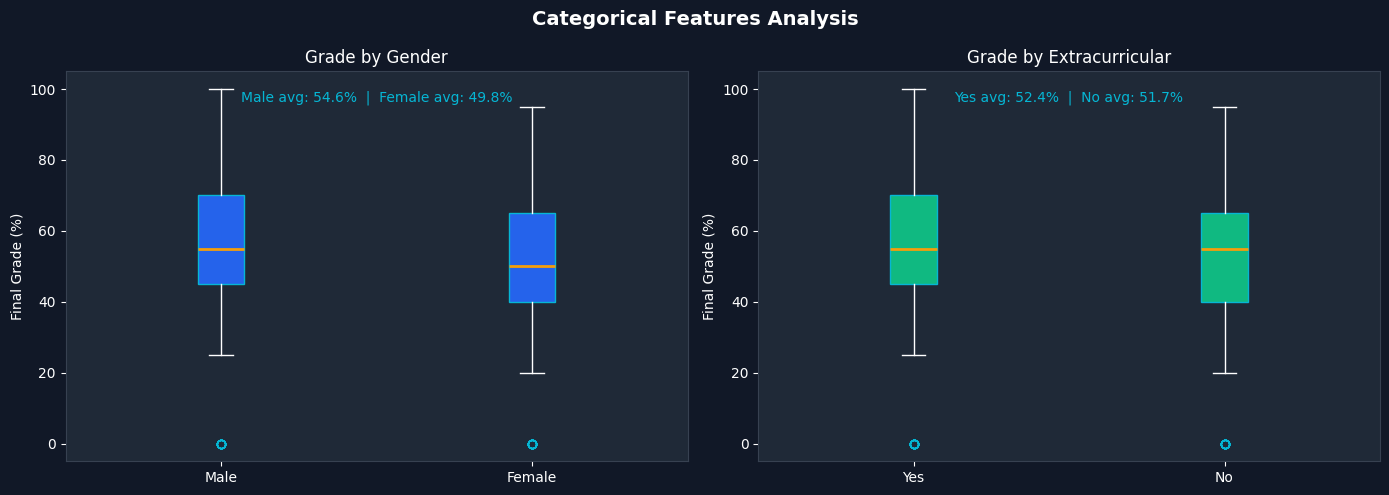

Saved: plots/categorical_analysis.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Categorical Features Analysis', color='white',
             fontsize=14, fontweight='bold')

# Gender vs Grade
gender_data = [df[df['gender']==1]['final_grade'].values,
               df[df['gender']==0]['final_grade'].values]
bp1 = axes[0].boxplot(gender_data, labels=['Male', 'Female'],
                       patch_artist=True,
                       boxprops=dict(facecolor=BLUE, color=CYAN),
                       medianprops=dict(color=AMBER, linewidth=2),
                       whiskerprops=dict(color='white'),
                       capprops=dict(color='white'),
                       flierprops=dict(color=CYAN, markeredgecolor=CYAN))
axes[0].set_ylabel('Final Grade (%)')
axes[0].set_title('Grade by Gender', color='white')
male_avg   = df[df['gender']==1]['final_grade'].mean()
female_avg = df[df['gender']==0]['final_grade'].mean()
axes[0].text(0.5, 0.95,
             f'Male avg: {male_avg:.1f}%  |  Female avg: {female_avg:.1f}%',
             transform=axes[0].transAxes, ha='center', va='top',
             color=CYAN, fontsize=10)

# Extracurricular vs Grade
extra_data = [df[df['extracurricular']==1]['final_grade'].values,
              df[df['extracurricular']==0]['final_grade'].values]
axes[1].boxplot(extra_data, labels=['Yes', 'No'],
                patch_artist=True,
                boxprops=dict(facecolor=GREEN, color=CYAN),
                medianprops=dict(color=AMBER, linewidth=2),
                whiskerprops=dict(color='white'),
                capprops=dict(color='white'),
                flierprops=dict(color=CYAN, markeredgecolor=CYAN))
axes[1].set_ylabel('Final Grade (%)')
axes[1].set_title('Grade by Extracurricular', color='white')
yes_avg = df[df['extracurricular']==1]['final_grade'].mean()
no_avg  = df[df['extracurricular']==0]['final_grade'].mean()
axes[1].text(0.5, 0.95,
             f'Yes avg: {yes_avg:.1f}%  |  No avg: {no_avg:.1f}%',
             transform=axes[1].transAxes, ha='center', va='top',
             color=CYAN, fontsize=10)

plt.tight_layout()
plt.savefig('../plots/categorical_analysis.png', dpi=150,
            bbox_inches='tight', facecolor='#111827')
plt.show()
print("Saved: plots/categorical_analysis.png")


## Step 9 — Feature Importance (Correlation-Based)

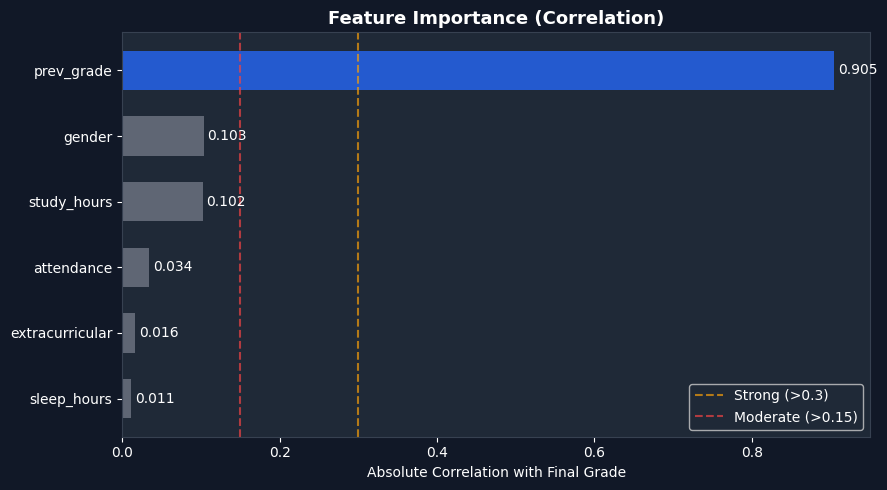

=== Feature Importance Ranking ===
  prev_grade          : 0.905  (Strong)
  gender              : 0.103  (Weak)
  study_hours         : 0.102  (Weak)
  attendance          : 0.034  (Weak)
  extracurricular     : 0.016  (Weak)
  sleep_hours         : 0.011  (Weak)


In [10]:
corr_vals = df[FEATURES].corrwith(df['final_grade']).abs().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))

bar_colors = [BLUE if v > 0.3 else CYAN if v > 0.15 else GRAY
              for v in corr_vals.values]

bars = ax.barh(corr_vals.index, corr_vals.values,
               color=bar_colors, alpha=0.85, height=0.6)

for bar, val in zip(bars, corr_vals.values):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', color='white', fontsize=10)

ax.set_xlabel('Absolute Correlation with Final Grade')
ax.set_title('Feature Importance (Correlation)', color='white',
             fontsize=13, fontweight='bold')
ax.axvline(0.3, color=AMBER, linestyle='--', alpha=0.7, label='Strong (>0.3)')
ax.axvline(0.15, color=RED,   linestyle='--', alpha=0.7, label='Moderate (>0.15)')
ax.legend()

plt.tight_layout()
plt.savefig('../plots/feature_importance.png', dpi=150,
            bbox_inches='tight', facecolor='#111827')
plt.show()

print("=== Feature Importance Ranking ===")
for feat, val in corr_vals.sort_values(ascending=False).items():
    level = "Strong" if val > 0.3 else "Moderate" if val > 0.15 else "Weak"
    print(f"  {feat:20s}: {val:.3f}  ({level})")


## Step 10 — EDA Summary & Key Insights

In [11]:
print("=" * 50)
print("EDA SUMMARY — KEY INSIGHTS")
print("=" * 50)
print()

print(f"Dataset: {len(df)} students")
print(f"Pass rate: {df['pass_fail'].mean()*100:.1f}%")
print(f"Average final grade: {df['final_grade'].mean():.1f}%")
print()

print("Top 3 features impacting grade:")
top3 = df[FEATURES].corrwith(df['final_grade']).abs().sort_values(ascending=False).head(3)
for i, (feat, val) in enumerate(top3.items(), 1):
    print(f"  {i}. {feat}: {val:.3f}")
print()

print("Grade by study hours:")
print(df.groupby('study_hours')['final_grade'].mean().round(1))
print()

print("Grade by attendance range:")
print(df.groupby('att_bin', observed=True)['final_grade'].mean().round(1))

print()
print("=" * 50)
print("All plots saved in plots/ folder")
print("Phase 2 COMPLETE!")
print("=" * 50)


EDA SUMMARY — KEY INSIGHTS

Dataset: 395 students
Pass rate: 67.1%
Average final grade: 52.1%

Top 3 features impacting grade:
  1. prev_grade: 0.905
  2. gender: 0.103
  3. study_hours: 0.102

Grade by study hours:
study_hours
1.5     50.2
3.5     50.9
7.5     57.0
12.0    56.3
Name: final_grade, dtype: float64

Grade by attendance range:
att_bin
<60%      46.0
60-75%    55.4
75-90%    52.5
>90%      51.9
Name: final_grade, dtype: float64

All plots saved in plots/ folder
Phase 2 COMPLETE!


## Phase 2 Complete

| Plot | File | Insight |
|------|------|---------|
| Grade Distribution | grade_distribution.png | 67% pass rate |
| Correlation Heatmap | correlation_heatmap.png | prev_grade most correlated |
| Study Hours Analysis | study_hours_analysis.png | More hours = better grades |
| Attendance Analysis | attendance_analysis.png | >90% attendance = best grades |
| Prev vs Final Grade | prev_vs_final_grade.png | Strong positive correlation |
| All Features vs Grade | all_features_vs_grade.png | Full picture |
| Categorical Analysis | categorical_analysis.png | Gender/extracurricular impact |
| Feature Importance | feature_importance.png | Ranking by correlation |

**Next: Phase 3 — ML Model Development (03_models.ipynb)**
